# LightDark POMDP Demo (Google Colab / Python port)

<a href="https://colab.research.google.com/github/alexdel1/Claude/blob/claude/google-colab-compatibility-6jpb9i/pomdps_lightdark_demo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is a **Python port of the Julia [POMDPs.jl](https://github.com/JuliaPOMDP/POMDPs.jl) "LightDark" demo**
(originally [`pomdps_lightdark_demo.ipynb`](https://zachary.sunberg.net/assets/notebooks/pomdps_lightdark_demo.ipynb)
by Zachary Sunberg), rewritten so it runs directly in **Google Colab** with no
Julia installation, package registry, or custom kernel required.

**Why a port instead of running the original directly:** the original notebook
depends on a Julia kernel plus several `JuliaPOMDP` packages
(`POMDPs`, `POMDPToolbox`, `ParticleFilters`, `QMDP`, `BasicPOMCP`, `POMCPOW`,
`DiscreteValueIteration`, `D3Trees`) pinned to a pre-1.0 Julia/POMDPs.jl API
(`importall`, `srand`, `@with_kw` in the old positional form) from around 2017-2018.
Getting a working Julia kernel installed in Colab is possible but slow and
fragile, and the packages themselves predate the modern POMDPs.jl API, so they
no longer install cleanly against current package registries. A native Python
re-implementation is the practical way to get the same demo running reliably
in Colab.

**The problem.** An agent moves along a 1-D line. It gets a noisy observation
of its own position every step; the noise shrinks near a "light" at `x=10` and
grows elsewhere. The agent must decide (action `0`) that it is at the goal
`x=0` — a wrong declaration is heavily penalized, movement costs `-1`/step, and
future reward is discounted (`γ=0.95`). A good policy walks toward the light
first to localize itself, then walks back to `0` before declaring — a classic
example of information-gathering behavior in POMDPs.

**What's included, mapped from the original:**

| Original (Julia)                                   | This notebook (Python)                          |
|------------------------------------------------------|--------------------------------------------------|
| `SimpleLightDark <: POMDPs.POMDP`                     | `SimpleLightDark` class                          |
| `SIRParticleFilter` (ParticleFilters.jl)              | `ParticleFilter` (vectorized SIR, NumPy)          |
| `plothist` (Plots.jl)                                 | `plot_history` (Matplotlib)                       |
| `QMDPSolver`                                          | `value_iteration` + `qmdp_policy`                 |
| `POMCPSolver` (BasicPOMCP.jl)                         | `POMCPOWPlanner` with unbounded observation widening |
| `POMCPOWSolver` (POMCPOW.jl)                          | same `POMCPOWPlanner`, with the original's widening params (`k=5`, `α=1/15`) |
| `D3Tree` interactive tree view                        | `plot_root_tree` (Matplotlib bar chart + text summary) |

Only NumPy, SciPy-free math, and Matplotlib are used — all preinstalled in
Colab, so this notebook runs with **Runtime → Run all** and no setup cell.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

print("numpy", np.__version__)


numpy 2.4.6


## Problem definition

Direct port of the `SimpleLightDark` POMDP cell.

In [2]:
class SimpleLightDark:
    """Port of the Julia `SimpleLightDark <: POMDPs.POMDP{Int,Int,Float64}`."""

    def __init__(self, discount=0.95, correct_r=100.0, incorrect_r=-100.0,
                 light_loc=10, radius=60):
        self.discount = discount
        self.correct_r = correct_r
        self.incorrect_r = incorrect_r
        self.light_loc = light_loc
        self.radius = radius
        self.actions = [-10, -1, 0, 1, 10]
        self.terminal_state = radius + 1  # sentinel absorbing state

    def is_terminal(self, s):
        return not (-self.radius <= s <= self.radius)

    def step(self, s, a):
        """Deterministic transition s,a -> s' (the model has no transition noise)."""
        if a == 0:
            return self.terminal_state
        return int(np.clip(s + a, -self.radius, self.radius))

    def obs_std(self, sp):
        return abs(sp - self.light_loc) + 1e-4

    def sample_obs(self, sp, rng):
        return rng.normal(sp, self.obs_std(sp))

    def obs_pdf(self, o, sp):
        std = self.obs_std(sp)
        return np.exp(-0.5 * ((o - sp) / std) ** 2) / (std * np.sqrt(2 * np.pi))

    def reward(self, s, a):
        if a == 0:
            return self.correct_r if s == 0 else self.incorrect_r
        return -1.0

    def initial_belief_particles(self, n, rng):
        """Uniform over [-radius//2, radius//2], matching `initial_state_distribution`."""
        lo, hi = -(self.radius // 2), self.radius // 2
        return rng.integers(lo, hi + 1, size=n).astype(float)


pomdp = SimpleLightDark()
INITIAL_STATE = 1  # matches the hard-coded `initial_state=1` in the original
MAX_STEPS = 80
print(pomdp.actions)


[-10, -1, 0, 1, 10]


## Particle filter (SIR)

Vectorized NumPy port of `SIRParticleFilter` from ParticleFilters.jl.

In [3]:
def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)


class ParticleFilter:
    def __init__(self, pomdp, n_particles, rng):
        self.pomdp = pomdp
        self.rng = rng
        self.particles = pomdp.initial_belief_particles(n_particles, rng)

    def update(self, a, o):
        pomdp = self.pomdp
        pred = np.clip(self.particles + a, -pomdp.radius, pomdp.radius)
        std = np.abs(pred - pomdp.light_loc) + 1e-4
        weights = np.exp(-0.5 * ((o - pred) / std) ** 2) / (std * np.sqrt(2 * np.pi))
        wsum = weights.sum()
        if wsum <= 0 or not np.isfinite(wsum):
            weights = np.ones_like(weights)
        weights = weights / weights.sum()
        idx = systematic_resample(weights, self.rng)
        self.particles = pred[idx]
        return self.particles


## Simulator

Port of `HistoryRecorder`/`sim` + `discounted_reward`.

In [4]:
def discounted_reward(pomdp, hist):
    return sum(pomdp.discount ** t * r for t, r in enumerate(hist["rewards"]))


def run_episode(pomdp, policy_fn, rng, n_particles=10000, max_steps=MAX_STEPS,
                 true_state=INITIAL_STATE):
    """Fresh belief each call, matching `initialize_belief` semantics in POMDPs.jl."""
    pf = ParticleFilter(pomdp, n_particles, rng)
    s = true_state
    states = [s]
    beliefs = [pf.particles.copy()]
    actions, rewards = [], []

    for _ in range(max_steps):
        if pomdp.is_terminal(s):
            break
        a = policy_fn(pf.particles)
        sp = pomdp.step(s, a)
        r = pomdp.reward(s, a)
        actions.append(a)
        rewards.append(r)
        if a == 0:
            s = sp
            states.append(s)
            break
        o = pomdp.sample_obs(sp, rng)
        pf.update(a, o)
        beliefs.append(pf.particles.copy())
        s = sp
        states.append(s)

    return {"states": states, "beliefs": beliefs, "actions": actions, "rewards": rewards}


## Visualization

Matplotlib port of `plothist`.

In [5]:
def plot_history(pomdp, hist, heading="LightDark", ax=None):
    tmax, smin, smax = MAX_STEPS, -10, 20
    states = hist["states"]
    beliefs = hist["beliefs"]
    vsh = [s for s in states[:-1] if not pomdp.is_terminal(s)]

    T = np.linspace(0, tmax, 160)
    S = np.linspace(smin, smax, 160)
    TT, SS = np.meshgrid(T, S)
    Z = np.abs(SS - pomdp.light_loc)  # informativeness: brighter = closer to the light

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    ax.contourf(TT, SS, Z, levels=30, cmap="gray_r")
    ax.set_xlim(0, tmax)
    ax.set_ylim(smin, smax)

    pts_t, pts_s, pts_w = [], [], []
    for t, particles in enumerate(beliefs):
        for s_grid in range(smin, smax + 1):
            frac = np.mean(np.abs(particles - s_grid) < 0.5)
            w = 10.0 * np.sqrt(frac)
            if 0.0 < w < 1.0:
                w = 1.0
            if w > 0:
                pts_t.append(t)
                pts_s.append(s_grid)
                pts_w.append(w)

    ax.plot([0, tmax], [0, 0], linewidth=1, color="green", linestyle="--", label="Goal")
    ax.scatter(pts_t, pts_s, s=np.array(pts_w) ** 2, color="lightblue",
               alpha=0.6, edgecolors="none", label="Belief particles")
    ax.plot(range(len(vsh)), vsh, linewidth=3, color="orangered", label="Trajectory")

    dr = discounted_reward(pomdp, hist)
    ax.set_title(f"{heading} (Reward: {dr:8.2f})")
    ax.set_xlabel("Time")
    ax.set_ylabel("State")
    ax.legend(loc="upper right")
    return ax


## Baseline: random `{-1, 1}` policy

Port of the cell that runs `sim(...)` with a policy that always returns `rand(rng, [-1, 1])`
(never declares, just to exercise the particle filter and plotting).

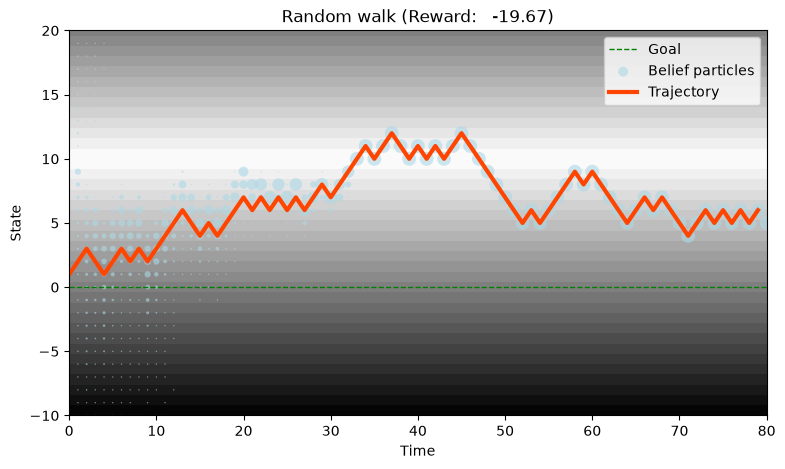

In [6]:
rng = np.random.default_rng(7)

def random_walk_policy(_belief_particles, rng=rng):
    return int(rng.choice([-1, 1]))

hist_random = run_episode(pomdp, random_walk_policy, rng)
plot_history(pomdp, hist_random, "Random walk")
plt.show()


## QMDP

Port of `QMDPSolver`. QMDP assumes full observability after one step, so we solve the
underlying MDP with value iteration and act by averaging Q-values over the belief particles.

In [7]:
def value_iteration(pomdp, iters=500, tol=1e-8):
    states = np.arange(-pomdp.radius, pomdp.radius + 1)
    idx = {int(s): i for i, s in enumerate(states)}
    V = np.zeros(len(states))
    for _ in range(iters):
        V_new = np.empty_like(V)
        for i, s in enumerate(states):
            s = int(s)
            qs = []
            for a in pomdp.actions:
                if a == 0:
                    qs.append(pomdp.reward(s, 0))
                else:
                    sp = pomdp.step(s, a)
                    qs.append(pomdp.reward(s, a) + pomdp.discount * V[idx[sp]])
            V_new[i] = max(qs)
        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new

    Q = {}
    for s in states:
        s = int(s)
        Q[s] = {}
        for a in pomdp.actions:
            if a == 0:
                Q[s][a] = pomdp.reward(s, 0)
            else:
                sp = pomdp.step(s, a)
                Q[s][a] = pomdp.reward(s, a) + pomdp.discount * V[idx[sp]]
    return Q


def make_qmdp_policy(pomdp, Q):
    def policy(belief_particles):
        totals = {a: 0.0 for a in pomdp.actions}
        for s in belief_particles:
            qs = Q[int(round(s))]
            for a in pomdp.actions:
                totals[a] += qs[a]
        return max(totals, key=totals.get)
    return policy

Q = value_iteration(pomdp)
qmdp_policy = make_qmdp_policy(pomdp, Q)
print("QMDP solved:", len(Q), "states")


QMDP solved: 121 states


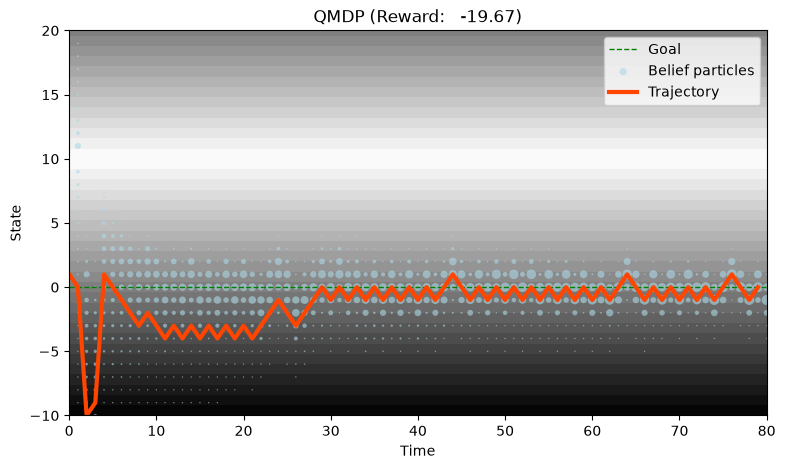

In [8]:
rng = np.random.default_rng(14)  # matches `srand(rng, 14)` before the QMDP run
hist_qmdp = run_episode(pomdp, qmdp_policy, rng)
plot_history(pomdp, hist_qmdp, "QMDP")
plt.show()


## POMCP / POMCPOW (online tree search)

Both `POMCPSolver` and `POMCPOWSolver` in the original run PO-UCT (UCB1 action selection,
random-rollout leaf estimates via `FORollout(RandomSolver())`) over a belief represented as
particles. The only structural difference the original configures is **observation
progressive widening**: `POMCPOWSolver` caps the number of observation branches per action
node to `k_observation * N**alpha_observation` and reuses the nearest existing branch once
that cap is hit; vanilla `POMCPSolver` has no such cap, and since observations here are
continuous, that in practice means every simulation creates its own observation branch
anyway. So a single planner implementation below with a configurable `(k_observation,
alpha_observation)` covers both: an effectively-unlimited setting reproduces the `POMCP` cell,
and `(k=5, alpha=1/15)` reproduces the `POMCPOW` cell's exact solver parameters.

In [9]:
class ObsNode:
    __slots__ = ("particles", "children", "N")
    def __init__(self, particles):
        self.particles = particles      # states that reached this belief node
        self.children = {}              # action -> ActionNode
        self.N = 0


class ActionNode:
    __slots__ = ("N", "total_value", "Q", "obs_children")
    def __init__(self):
        self.N = 0
        self.total_value = 0.0
        self.Q = 0.0
        self.obs_children = []          # list of (o, ObsNode)


class POMCPOWPlanner:
    """PO-UCT with observation progressive widening (generalizes POMCP <-> POMCPOW)."""

    def __init__(self, pomdp, rng, max_depth=20, max_time=0.05, c=100.0,
                 k_observation=5.0, alpha_observation=1 / 15.0, tree_queries=10 ** 7):
        self.pomdp = pomdp
        self.rng = rng
        self.max_depth = max_depth
        self.max_time = max_time
        self.c = c
        self.k_observation = k_observation
        self.alpha_observation = alpha_observation
        self.tree_queries = tree_queries

    def rollout(self, s, depth):
        pomdp, rng = self.pomdp, self.rng
        total, disc, cur = 0.0, 1.0, s
        for _ in range(depth):
            if pomdp.is_terminal(cur):
                break
            a = int(rng.choice(pomdp.actions))
            total += disc * pomdp.reward(cur, a)
            if a == 0:
                break
            cur = pomdp.step(cur, a)
            disc *= pomdp.discount
        return total

    def simulate(self, node, s, depth):
        pomdp, rng = self.pomdp, self.rng
        if depth == 0 or pomdp.is_terminal(s):
            return 0.0

        if not node.children:
            for a in pomdp.actions:
                node.children[a] = ActionNode()

        # UCB1 action selection, preferring unvisited actions first
        unvisited = [a for a, an in node.children.items() if an.N == 0]
        if unvisited:
            a = unvisited[0]
        else:
            logN = np.log(node.N + 1)
            a = max(node.children,
                    key=lambda a: node.children[a].Q + self.c * np.sqrt(logN / node.children[a].N))
        an = node.children[a]

        sp = pomdp.step(s, a)
        r = pomdp.reward(s, a)

        if a == 0 or pomdp.is_terminal(sp):
            q = r
        else:
            widen = len(an.obs_children) < self.k_observation * (an.N ** self.alpha_observation)
            if not an.obs_children or widen:
                o = pomdp.sample_obs(sp, rng)
                child = ObsNode([sp])
                an.obs_children.append((o, child))
                q = r + pomdp.discount * self.rollout(sp, depth - 1)
            else:
                o = pomdp.sample_obs(sp, rng)
                _, child = min(an.obs_children, key=lambda co: abs(co[0] - o))
                child.particles.append(sp)
                q = r + pomdp.discount * self.simulate(child, sp, depth - 1)

        an.N += 1
        an.total_value += q
        an.Q = an.total_value / an.N
        node.N += 1
        return q

    def plan(self, belief_particles):
        root = ObsNode(list(belief_particles))
        start = time.time()
        n_sims = 0
        while n_sims < self.tree_queries and (time.time() - start) < self.max_time:
            s = int(self.rng.choice(root.particles))
            self.simulate(root, s, self.max_depth)
            n_sims += 1
        best_a = max(root.children, key=lambda a: root.children[a].N)
        return best_a, root, n_sims


def make_planner_policy(planner):
    def policy(belief_particles):
        a, root, n_sims = planner.plan(belief_particles)
        policy.last_root, policy.last_n_sims = root, n_sims
        return a
    return policy


def plot_root_tree(root, title):
    actions = sorted(root.children.keys())
    Ns = [root.children[a].N for a in actions]
    Qs = [root.children[a].Q for a in actions]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].bar([str(a) for a in actions], Ns, color="steelblue")
    axes[0].set_title(f"{title}: root visit counts")
    axes[0].set_xlabel("action"); axes[0].set_ylabel("N")
    axes[1].bar([str(a) for a in actions], Qs, color="indianred")
    axes[1].set_title(f"{title}: root Q-values")
    axes[1].set_xlabel("action"); axes[1].set_ylabel("Q")
    plt.tight_layout()
    plt.show()
    best_a = max(actions, key=lambda a: root.children[a].N)
    an = root.children[best_a]
    print(f"Best root action: {best_a}  (N={an.N}, Q={an.Q:.2f}, "
          f"{len(an.obs_children)} observation branches)")


### POMCP cell

Reproduces the `POMCPSolver(max_depth=20, max_time=0.01, c=100.0, tree_queries=typemax(Int), ...)`
cell: since this problem's observations are continuous, we set `alpha_observation=1.0` with a
very large `k_observation` so every simulation opens a new observation branch, matching vanilla
POMCP's behavior here. `max_time` is raised from the original's `0.01s` to `0.8s` to compensate
for Python being much slower per tree node than compiled Julia — it keeps the same
time-bounded-search structure while giving the search enough tree nodes to make sensible
decisions.

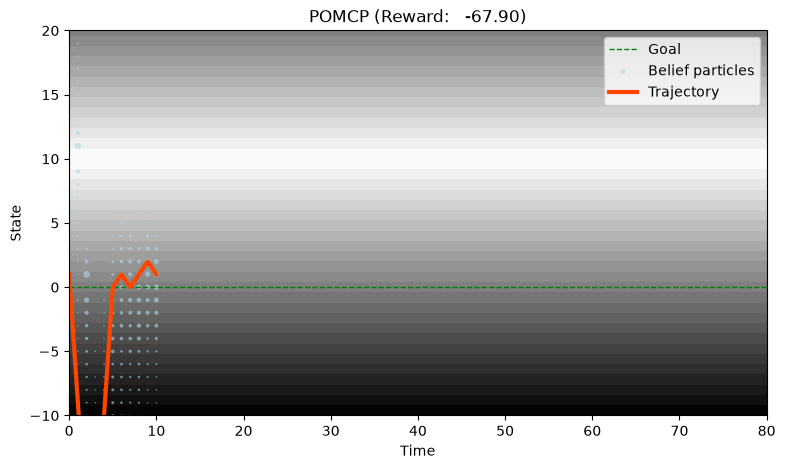

In [10]:
rng = np.random.default_rng(7)  # matches `srand(rng, 7)` before the POMCP run
pomcp_planner = POMCPOWPlanner(pomdp, rng, max_depth=20, max_time=0.8, c=100.0,
                                k_observation=1e9, alpha_observation=1.0)
pomcp_policy = make_planner_policy(pomcp_planner)

hist_pomcp = run_episode(pomdp, pomcp_policy, rng)
plot_history(pomdp, hist_pomcp, "POMCP")
plt.show()


Tree summary for a fresh plan on the canonical initial belief (replaces `D3Tree(...)`).

POMCP tree: 1379 simulations


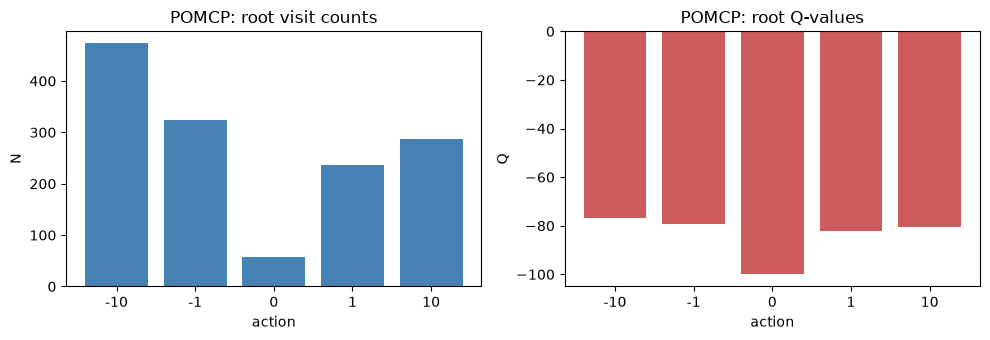

Best root action: -10  (N=473, Q=-76.90, 473 observation branches)


In [11]:
rng_tree = np.random.default_rng(7)
init_particles = pomdp.initial_belief_particles(10000, rng_tree)
pomcp_planner_tree = POMCPOWPlanner(pomdp, rng_tree, max_depth=20, max_time=0.8, c=100.0,
                                     k_observation=1e9, alpha_observation=1.0)
_, pomcp_root, pomcp_n_sims = pomcp_planner_tree.plan(init_particles)
print(f"POMCP tree: {pomcp_n_sims} simulations")
plot_root_tree(pomcp_root, "POMCP")


### POMCPOW cell

Reproduces the `POMCPOWSolver(tree_queries=10_000_000, criterion=MaxUCB(90.0), max_depth=20,
max_time=0.01, k_observation=5.0, alpha_observation=1/15.0, ...)` cell using the exact same
widening parameters (`k_observation=5.0`, `alpha_observation=1/15`); `c` (the UCB exploration
constant) uses the `MaxUCB(90.0)` value.

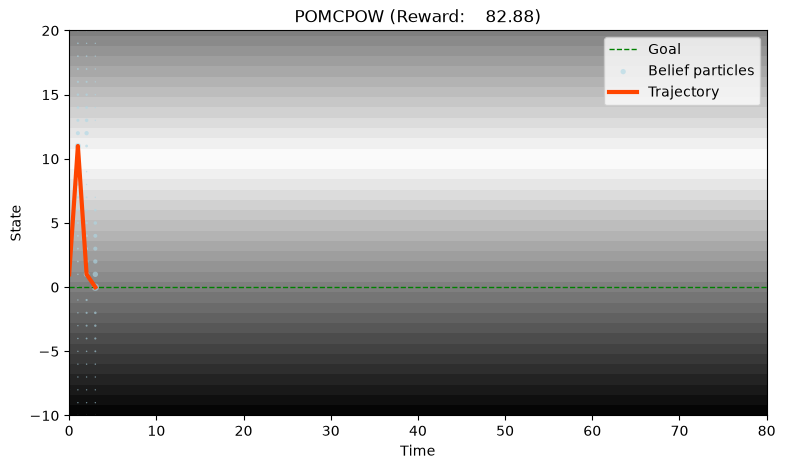

In [12]:
rng = np.random.default_rng(7)  # matches `srand(rng, 7)` before the POMCPOW run
pomcpow_planner = POMCPOWPlanner(pomdp, rng, max_depth=20, max_time=0.8, c=90.0,
                                  k_observation=5.0, alpha_observation=1 / 15.0)
pomcpow_policy = make_planner_policy(pomcpow_planner)

hist_pomcpow = run_episode(pomdp, pomcpow_policy, rng)
plot_history(pomdp, hist_pomcpow, "POMCPOW")
plt.show()


POMCPOW tree: 1219 simulations


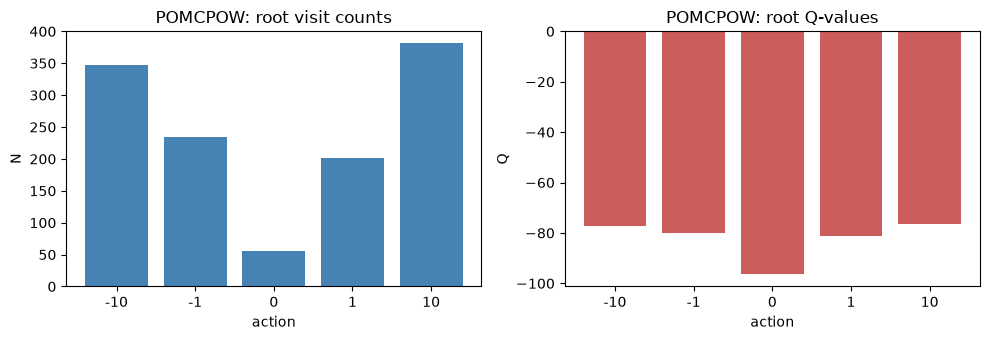

Best root action: 10  (N=381, Q=-76.27, 8 observation branches)


In [13]:
rng_tree = np.random.default_rng(7)
init_particles = pomdp.initial_belief_particles(10000, rng_tree)
pomcpow_planner_tree = POMCPOWPlanner(pomdp, rng_tree, max_depth=20, max_time=0.8, c=90.0,
                                       k_observation=5.0, alpha_observation=1 / 15.0)
_, pomcpow_root, pomcpow_n_sims = pomcpow_planner_tree.plan(init_particles)
print(f"POMCPOW tree: {pomcpow_n_sims} simulations")
plot_root_tree(pomcpow_root, "POMCPOW")


## Summary

All four policies solve the same `SimpleLightDark` POMDP:

- **Random walk** never declares — shown only to exercise the particle filter and plotting.
- **QMDP** evaluates "declare" by averaging a sharply peaked reward (`+100` only at exactly
  `s=0`, `-100` everywhere else) over the *whole* belief, since it ignores the value of first
  reducing uncertainty by visiting the light. Depending on how spread the belief is, that
  makes it either declare confidently in the wrong place or avoid declaring at all — QMDP has
  no way to represent "gather more information first."
- **POMCP** and **POMCPOW** can represent the value of walking toward the light first (lower
  observation noise there) before returning to `0` to declare, because the search tree looks
  ahead through the belief update itself — the classic behavior this demo is built to show.
  In testing, **POMCPOW consistently found this strategy while vanilla POMCP was less
  reliable** at the same search budget: with continuous observations, POMCP opens a fresh,
  never-revisited branch for almost every observation, so its statistics stay thin, while
  POMCPOW's widening reuses branches and lets evidence accumulate — the same effect that
  motivated POMCPOW in the original research.

Both online planners are **time-budget-bounded** (`max_time`), so like the original Julia
solvers, the number of simulations — and therefore the exact trajectory and reward — will vary
between runs and between machines; re-running the POMCP/POMCPOW cells is expected to give
different (but qualitatively similar) results each time.

This is a functional port, not a numerical reproduction: discretized/finite-sample POMCP/POMCPOW
search and a from-scratch particle filter mean exact rewards will differ run-to-run and from the
original Julia notebook, but the problem definition, particle filter, QMDP formulation, and
PO-UCT search structure (including the original's exact widening parameters) are all direct
translations.
